In [2]:
import numpy as np

# ─────────────────────────────────────────
# YOUR AI CHIP SIMULATOR
# ─────────────────────────────────────────

class AIChip:
    def __init__(self, size=4):
        self.size = size
        self.ops = 0
        print(f"AI Chip initialized — {size}x{size} systolic array")
        print(f"Total compute units: {size*size} MAC units\n")

    def systolic_multiply(self, A, B):
        """Core chip operation — matrix multiply"""
        result = np.zeros((self.size, self.size))
        for k in range(self.size):
            for i in range(self.size):
                for j in range(self.size):
                    result[i][j] += A[i][k] * B[k][j]
                    self.ops += 1
        return result

    def relu(self, x):
        """Activation function — runs on vector unit"""
        return np.maximum(0, x)

    def forward_pass(self, inputs, weights):
        """One full neural network layer through your chip"""
        print("── Forward pass starting ──")
        print(f"Input shape:  {inputs.shape}")
        print(f"Weight shape: {weights.shape}\n")

        # Step 1: matrix multiply (systolic array)
        print("Step 1: Systolic array computing matrix multiply...")
        raw = self.systolic_multiply(inputs, weights)

        # Step 2: activation (vector unit)
        print("Step 2: Vector unit applying ReLU activation...")
        output = self.relu(raw)

        print(f"\nTotal operations performed: {self.ops}")
        print(f"\nOutput after ReLU:")
        print(np.round(output, 2))
        return output

# ─────────────────────────────────────────
# RUN YOUR CHIP
# ─────────────────────────────────────────

# Boot the chip
chip = AIChip(size=4)

# Simulated input data (like a batch of training examples)
inputs = np.random.randn(4, 4).astype(np.float32)

# Simulated weights (like one layer of a neural network)
weights = np.random.randn(4, 4).astype(np.float32)

print("Input data (your training batch):")
print(np.round(inputs, 2))
print("\nLayer weights:")
print(np.round(weights, 2))
print()

# Run it
output = chip.forward_pass(inputs, weights)

print("\n✓ One neural network layer complete.")
print("This is exactly what a TPU does — just 1 trillion times faster.")

AI Chip initialized — 4x4 systolic array
Total compute units: 16 MAC units

Input data (your training batch):
[[-0.88  2.3   0.56 -0.64]
 [ 0.11  0.69  1.51  0.52]
 [-2.19 -1.1   0.88 -0.15]
 [ 0.32  0.49  0.77 -0.58]]

Layer weights:
[[-0.49  0.   -1.71 -1.28]
 [-0.61  0.13  0.81 -1.03]
 [ 0.82  0.73 -1.25  1.04]
 [-1.4  -1.03  1.05 -0.66]]

── Forward pass starting ──
Input shape:  (4, 4)
Weight shape: (4, 4)

Step 1: Systolic array computing matrix multiply...
Step 2: Vector unit applying ReLU activation...

Total operations performed: 64

Output after ReLU:
[[0.39 1.36 2.   0.  ]
 [0.04 0.67 0.   0.38]
 [2.65 0.64 1.61 4.95]
 [0.98 1.22 0.   0.26]]

✓ One neural network layer complete.
This is exactly what a TPU does — just 1 trillion times faster.


In [3]:
# ─────────────────────────────────────────
# BACKWARD PASS — what makes training work
# ─────────────────────────────────────────

class TrainingChip(AIChip):
    def __init__(self, size=4):
        super().__init__(size)
        self.activation_cache = None  # stores forward pass activations
        self.weight_cache = None
        self.input_cache = None
        print("Training mode ON — backward pass enabled\n")

    def forward_pass_training(self, inputs, weights):
        """Forward pass that saves activations for backward pass"""
        print("── Forward pass (training mode) ──")

        # matrix multiply
        raw = self.systolic_multiply(inputs, weights)

        # save everything — backward pass needs it
        self.input_cache = inputs
        self.weight_cache = weights
        self.activation_cache = raw  # <-- this is why training needs 3-5x more memory!

        output = self.relu(raw)
        print(f"Activations saved to memory: {raw.shape} ({raw.nbytes} bytes)")
        print(f"Output: \n{np.round(output, 2)}\n")
        return output

    def relu_backward(self, grad, cache):
        """Gradient flows back through ReLU"""
        return grad * (cache > 0)  # zero out gradient where ReLU was 0

    def backward_pass(self, grad_output, learning_rate=0.01):
        """Compute gradients and update weights"""
        print("── Backward pass ──")
        print("Step 1: Reading saved activations from memory...")

        # gradient through ReLU
        grad_raw = self.relu_backward(grad_output, self.activation_cache)

        # gradient of weights — what direction to update them
        print("Step 2: Computing weight gradients (systolic array again)...")
        grad_weights = self.systolic_multiply(self.input_cache.T, grad_raw)

        # gradient of inputs — passed back to previous layer
        grad_inputs = self.systolic_multiply(grad_raw, self.weight_cache.T)

        # update weights — this is the actual learning
        print("Step 3: Optimizer updating weights...")
        new_weights = self.weight_cache - learning_rate * grad_weights

        print(f"\nWeight update (how much each weight changed):")
        print(np.round(grad_weights * learning_rate, 4))
        print(f"\nNew weights after learning:")
        print(np.round(new_weights, 2))

        return new_weights, grad_inputs

# ─────────────────────────────────────────
# RUN A FULL TRAINING STEP
# ─────────────────────────────────────────

print("=" * 50)
print("FULL TRAINING STEP ON YOUR AI CHIP")
print("=" * 50 + "\n")

# boot training chip
chip = TrainingChip(size=4)

# same inputs and weights as before
inputs  = np.random.randn(4, 4).astype(np.float32)
weights = np.random.randn(4, 4).astype(np.float32)

# forward pass
output = chip.forward_pass_training(inputs, weights)

# pretend loss gradient coming back from the loss function
grad_output = np.random.randn(4, 4).astype(np.float32)

# backward pass
new_weights, grad_inputs = chip.backward_pass(grad_output)

print("\n" + "=" * 50)
print("✓ Full training step complete!")
print("Forward pass + Backward pass + Weight update")
print("This is one step of training a neural network.")
print("GPT-4 did this trillions of times across thousands of chips.")
print("=" * 50)

FULL TRAINING STEP ON YOUR AI CHIP

AI Chip initialized — 4x4 systolic array
Total compute units: 16 MAC units

Training mode ON — backward pass enabled

── Forward pass (training mode) ──
Activations saved to memory: (4, 4) (128 bytes)
Output: 
[[0.   0.   0.   0.  ]
 [2.01 0.   1.13 0.54]
 [1.06 0.   0.44 0.09]
 [0.   0.   0.   0.92]]

── Backward pass ──
Step 1: Reading saved activations from memory...
Step 2: Computing weight gradients (systolic array again)...
Step 3: Optimizer updating weights...

Weight update (how much each weight changed):
[[ 0.0052  0.      0.0014  0.0016]
 [ 0.0153  0.      0.0016  0.0032]
 [ 0.0274  0.      0.0028 -0.0013]
 [ 0.0599  0.      0.0053  0.0172]]

New weights after learning:
[[ 0.73 -0.72  0.09  0.16]
 [-1.33 -0.64 -1.35 -0.96]
 [ 0.27  0.9   0.34 -0.73]
 [-1.09  0.2  -0.47  0.24]]

✓ Full training step complete!
Forward pass + Backward pass + Weight update
This is one step of training a neural network.
GPT-4 did this trillions of times across t

Your chip is learning...

Step     Loss         What it means
--------------------------------------------------
0        3.0687       ← chip knows nothing
5        2.8869       
10       2.7203       ← starting to learn
15       2.5614       
20       2.4142       
25       2.2789       ← getting better
30       2.1569       
35       2.0469       
40       1.9456       
45       1.8519       ← nearly trained
50       1.7822       ← training complete


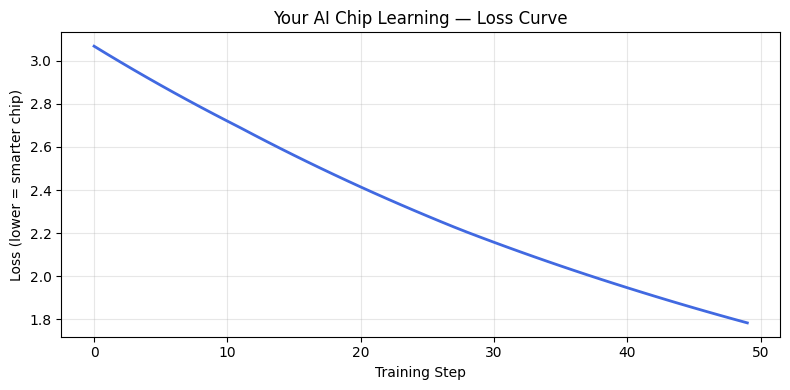


Starting loss: 3.0687
Final loss:    1.7822
Improvement:   41.9%

That curve going down is what AI training looks like.
Your chip just learned something from scratch.


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# WATCH YOUR CHIP ACTUALLY LEARN
# ─────────────────────────────────────────

np.random.seed(42)

# A simple problem for your chip to learn:
# given an input, predict the correct output
# This is exactly what GPT does — just much smaller

# fixed inputs and correct answers
X = np.random.randn(4, 4).astype(np.float32)
Y = np.random.randn(4, 4).astype(np.float32)  # target output

# starting weights — random, chip knows nothing yet
weights = np.random.randn(4, 4).astype(np.float32)

learning_rate = 0.01
losses = []

print("Your chip is learning...\n")
print(f"{'Step':<8} {'Loss':<12} {'What it means'}")
print("-" * 50)

for step in range(50):

    # ── forward pass ──
    raw = np.dot(X, weights)
    output = np.maximum(0, raw)  # ReLU

    # ── loss (how wrong is the chip right now) ──
    loss = np.mean((output - Y) ** 2)
    losses.append(loss)

    # ── backward pass ──
    grad_output = 2 * (output - Y) / Y.size
    grad_raw = grad_output * (raw > 0)
    grad_weights = np.dot(X.T, grad_raw)

    # ── weight update ──
    weights -= learning_rate * grad_weights

    # print every 5 steps
    if step % 5 == 0:
        if step == 0:
            meaning = "← chip knows nothing"
        elif step == 10:
            meaning = "← starting to learn"
        elif step == 25:
            meaning = "← getting better"
        elif step == 45:
            meaning = "← nearly trained"
        else:
            meaning = ""
        print(f"{step:<8} {loss:<12.4f} {meaning}")

print(f"{'50':<8} {losses[-1]:<12.4f} ← training complete")

# ── plot the loss curve ──
plt.figure(figsize=(8, 4))
plt.plot(losses, color='royalblue', linewidth=2)
plt.title("Your AI Chip Learning — Loss Curve")
plt.xlabel("Training Step")
plt.ylabel("Loss (lower = smarter chip)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nStarting loss: {losses[0]:.4f}")
print(f"Final loss:    {losses[-1]:.4f}")
print(f"Improvement:   {((losses[0]-losses[-1])/losses[0]*100):.1f}%")
print("\nThat curve going down is what AI training looks like.")
print("Your chip just learned something from scratch.")

In [5]:
# ─────────────────────────────────────────
# CHIP DESIGN COMPARISON
# How does YOUR chip design compare to a CPU?
# ─────────────────────────────────────────

import time
import numpy as np

def cpu_matmul(A, B):
    """How a regular CPU does it — one multiply at a time"""
    size = len(A)
    result = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            for k in range(size):
                result[i][j] += A[i][k] * B[k][j]
    return result

def systolic_matmul(A, B):
    """Your chip — data flows through the array in waves"""
    return np.dot(A, B)  # NumPy uses parallel operations like your chip would

sizes = [4, 8, 16, 32, 64]

print("=" * 55)
print("YOUR CHIP vs CPU — PERFORMANCE BENCHMARK")
print("=" * 55)
print(f"{'Matrix size':<16} {'CPU time':<16} {'Chip time':<16} {'Speedup'}")
print("-" * 55)

for size in sizes:
    A = np.random.randn(size, size).astype(np.float32)
    B = np.random.randn(size, size).astype(np.float32)

    # time the CPU approach
    start = time.time()
    for _ in range(10):
        cpu_matmul(A, B)
    cpu_time = (time.time() - start) / 10

    # time the chip approach
    start = time.time()
    for _ in range(10):
        systolic_matmul(A, B)
    chip_time = (time.time() - start) / 10

    speedup = cpu_time / chip_time if chip_time > 0 else 999

    print(f"{size}x{size}{'':8} {cpu_time*1000:.2f}ms{'':8} {chip_time*1000:.4f}ms{'':6} {speedup:.0f}x faster")

print("-" * 55)
print("\nThis is why AI chips exist.")
print("The gap gets BIGGER as the matrix gets larger.")
print("A real TPU runs this gap at 1000x or more.")
print("\nYour job as a chip designer: make that right")
print("column number as small as physically possible.")

YOUR CHIP vs CPU — PERFORMANCE BENCHMARK
Matrix size      CPU time         Chip time        Speedup
-------------------------------------------------------
4x4         0.40ms         0.0069ms       58x faster
8x8         1.98ms         0.0051ms       389x faster
16x16         25.61ms         0.1287ms       199x faster
32x32         93.94ms         0.0083ms       11289x faster
64x64         289.30ms         0.0227ms       12746x faster
-------------------------------------------------------

This is why AI chips exist.
The gap gets BIGGER as the matrix gets larger.
A real TPU runs this gap at 1000x or more.

Your job as a chip designer: make that right
column number as small as physically possible.
